## Imports, reading data etc

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL

In [29]:
df2906_1 = pd.read_csv('../data/labeled/no_plug/2906-1.csv')
df3006_1 = pd.read_csv('../data/labeled/no_plug/3006-1.csv')
df3006_2 = pd.read_csv('../data/labeled/no_plug/3006-2.csv')
df0404 = pd.read_csv('../data/labeled/no_plug/0404.csv')
df0712 = pd.read_csv('../data/labeled/no_plug/0712.csv')
df1703 = pd.read_csv('../data/labeled/no_plug/1703.csv')

df1803 = pd.read_csv('../data/labeled/partial_plug/1803.csv')
df1103 = pd.read_csv('../data/labeled/partial_plug/1103.csv')
df2503 = pd.read_csv('../data/labeled/partial_plug/2503.csv')
df2108_1 = pd.read_csv('../data/labeled/partial_plug/2108-1.csv')

df0709 = pd.read_csv('../data/labeled/plug/0709.csv')
df2106_2 = pd.read_csv('../data/labeled/plug/2106-2.csv')
df2108_2 = pd.read_csv('../data/labeled/plug/2108-2.csv')
df2906_2 = pd.read_csv('../data/labeled/plug/2906-2.csv')
df2906_3 = pd.read_csv('../data/labeled/plug/2906-3.csv')
df2906_4 = pd.read_csv('../data/labeled/plug/2906-4.csv')
df3006_3 = pd.read_csv('../data/labeled/plug/3006-3.csv')
df0612_2 = pd.read_csv('../data/labeled/plug/0612-2.csv')
df0612_3 = pd.read_csv('../data/labeled/plug/0612-3.csv')
df0707_1 = pd.read_csv('../data/labeled/plug/0707-1.csv')
df0707_2 = pd.read_csv('../data/labeled/plug/0707-2.csv')
df0707_4 = pd.read_csv('../data/labeled/plug/0707-4.csv')
df1112 = pd.read_csv('../data/labeled/plug/1112.csv')
df1310_2 = pd.read_csv('../data/labeled/plug/1310-2.csv')
df1310_3 = pd.read_csv('../data/labeled/plug/1310-3.csv')
df1407_1 = pd.read_csv('../data/labeled/plug/1407-1.csv')
df1407_2 = pd.read_csv('../data/labeled/plug/1407-2.csv')
df1407_3 = pd.read_csv('../data/labeled/plug/1407-3.csv')
df1407_4 = pd.read_csv('../data/labeled/plug/1407-4.csv')
df1503 = pd.read_csv('../data/labeled/plug/1503.csv')
df1811 = pd.read_csv('../data/labeled/plug/1811.csv')
df2701 = pd.read_csv('../data/labeled/plug/2701.csv')
df1003 = pd.read_csv('../data/labeled/plug/1003.csv')

In [30]:
no_plug_dfs = [df1703, df2906_1, df3006_1, df3006_2, df0404, df0712]

no_plug_names = ['1703', '2906-1', '3006-1', '3006-2', '0404', '0712']

plug_dfs = [df1003, df0709, df2106_2, df2108_2, df2906_2, df2906_3, df2906_4, 
            df3006_3, df0612_2, df0612_3, df0707_1, df0707_2, df0707_4, df1112, 
            df1310_2, df1310_3, df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2701]

plug_names = ['1003', '0709', '2106-2', '2108-2', '2906-2', '2906-3', '2906-4',
           '3006-3', '0612-2', '0612-3', '0707-1', '0707-2', '0707-4', '1112',
           '1310-2', '1310-3', '1407-1', '1407-2', '1407-3', '1407-4', '1503', '1811', '2701']

partial_plug_dfs = [df1803, df1103, df2503, df2108_1]
partial_plug_names = ['1803', '1103', '2503', '2108-1']

In [31]:
for i in range(len(partial_plug_dfs)):
    if partial_plug_dfs[0].columns.all() != partial_plug_dfs[i].columns.all():
        print('mismatch!')
for i in range(len(no_plug_dfs)):
    if no_plug_dfs[0].columns.all() != no_plug_dfs[i].columns.all():
        print('mismatch!')
for i in range(len(plug_dfs)):
    if plug_dfs[0].columns.all() != plug_dfs[i].columns.all():
        print('mismatch!')

## Unsupervised 

In [32]:
def extract_features(df):
    temp = df.copy()
    
    baseline = temp.iloc[:60]

    temp['rel_tot_dp_change'] = temp['Total system DP'] / baseline['Total system DP'].median()
    temp['rel_ts_dp_change'] = temp['Differential pressure (Mean)'] / baseline['Differential pressure (Mean)'].median()
    temp['rel_p_ts_dp_change'] = temp['Pump to inlet DP'] / baseline['Pump to inlet DP'].median()
    
    # 2. Temperature Delta (Thermal signature)
    temp['temp_delta'] = temp['Temperature TS outlet (Mean)'] - temp['Temperature TS inlet (Mean)']
    

    feature_cols = [
        'rel_tot_dp_change', 'rel_ts_dp_change', 'rel_p_ts_dp_change', 
        'Relative_Ratio_Dev'
    ]
    
    return temp, feature_cols


In [64]:
# --- STEP A: Feature Extraction for all Clean Runs ---
processed_no_plug = [extract_features(df)[0] for df in no_plug_dfs]
feature_cols = extract_features(no_plug_dfs[0])[1]

# --- STEP B: Fit Scaler and Model on CLEAN data only ---
all_clean_data = pd.concat(processed_no_plug)
scaler = StandardScaler()
X_clean_scaled = scaler.fit_transform(all_clean_data[feature_cols])

# Train the "Detector"
# contamination=0.01 implies we expect 1% noise even in clean data
iso_model = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
iso_model.fit(X_clean_scaled)

IsolationForest(contamination=0.01, n_estimators=200, random_state=42)

In [65]:
def apply_anomaly_scoring(df_list, model, scaler, features):
    scored_list = []
    for df in df_list:
        # 1. Extract the relative DP/Temp features
        temp, _ = extract_features(df)
        
        # 2. Scale using the GLOBAL scaler
        X_scaled = scaler.transform(temp[features])
        
        # 3. Calculate score (decision_function: lower is more anomalous)
        temp['anomaly_score'] = model.decision_function(X_scaled)
        
        temp['smooth_score'] = temp['anomaly_score'].rolling(window=3, center=True).mean().fillna(temp['anomaly_score'])
        
        scored_list.append(temp)
    return scored_list

# Apply to all categories
scored_no_plug = apply_anomaly_scoring(no_plug_dfs, iso_model, scaler, feature_cols)
scored_plug = apply_anomaly_scoring(plug_dfs, iso_model, scaler, feature_cols)
scored_partial = apply_anomaly_scoring(partial_plug_dfs, iso_model, scaler, feature_cols)

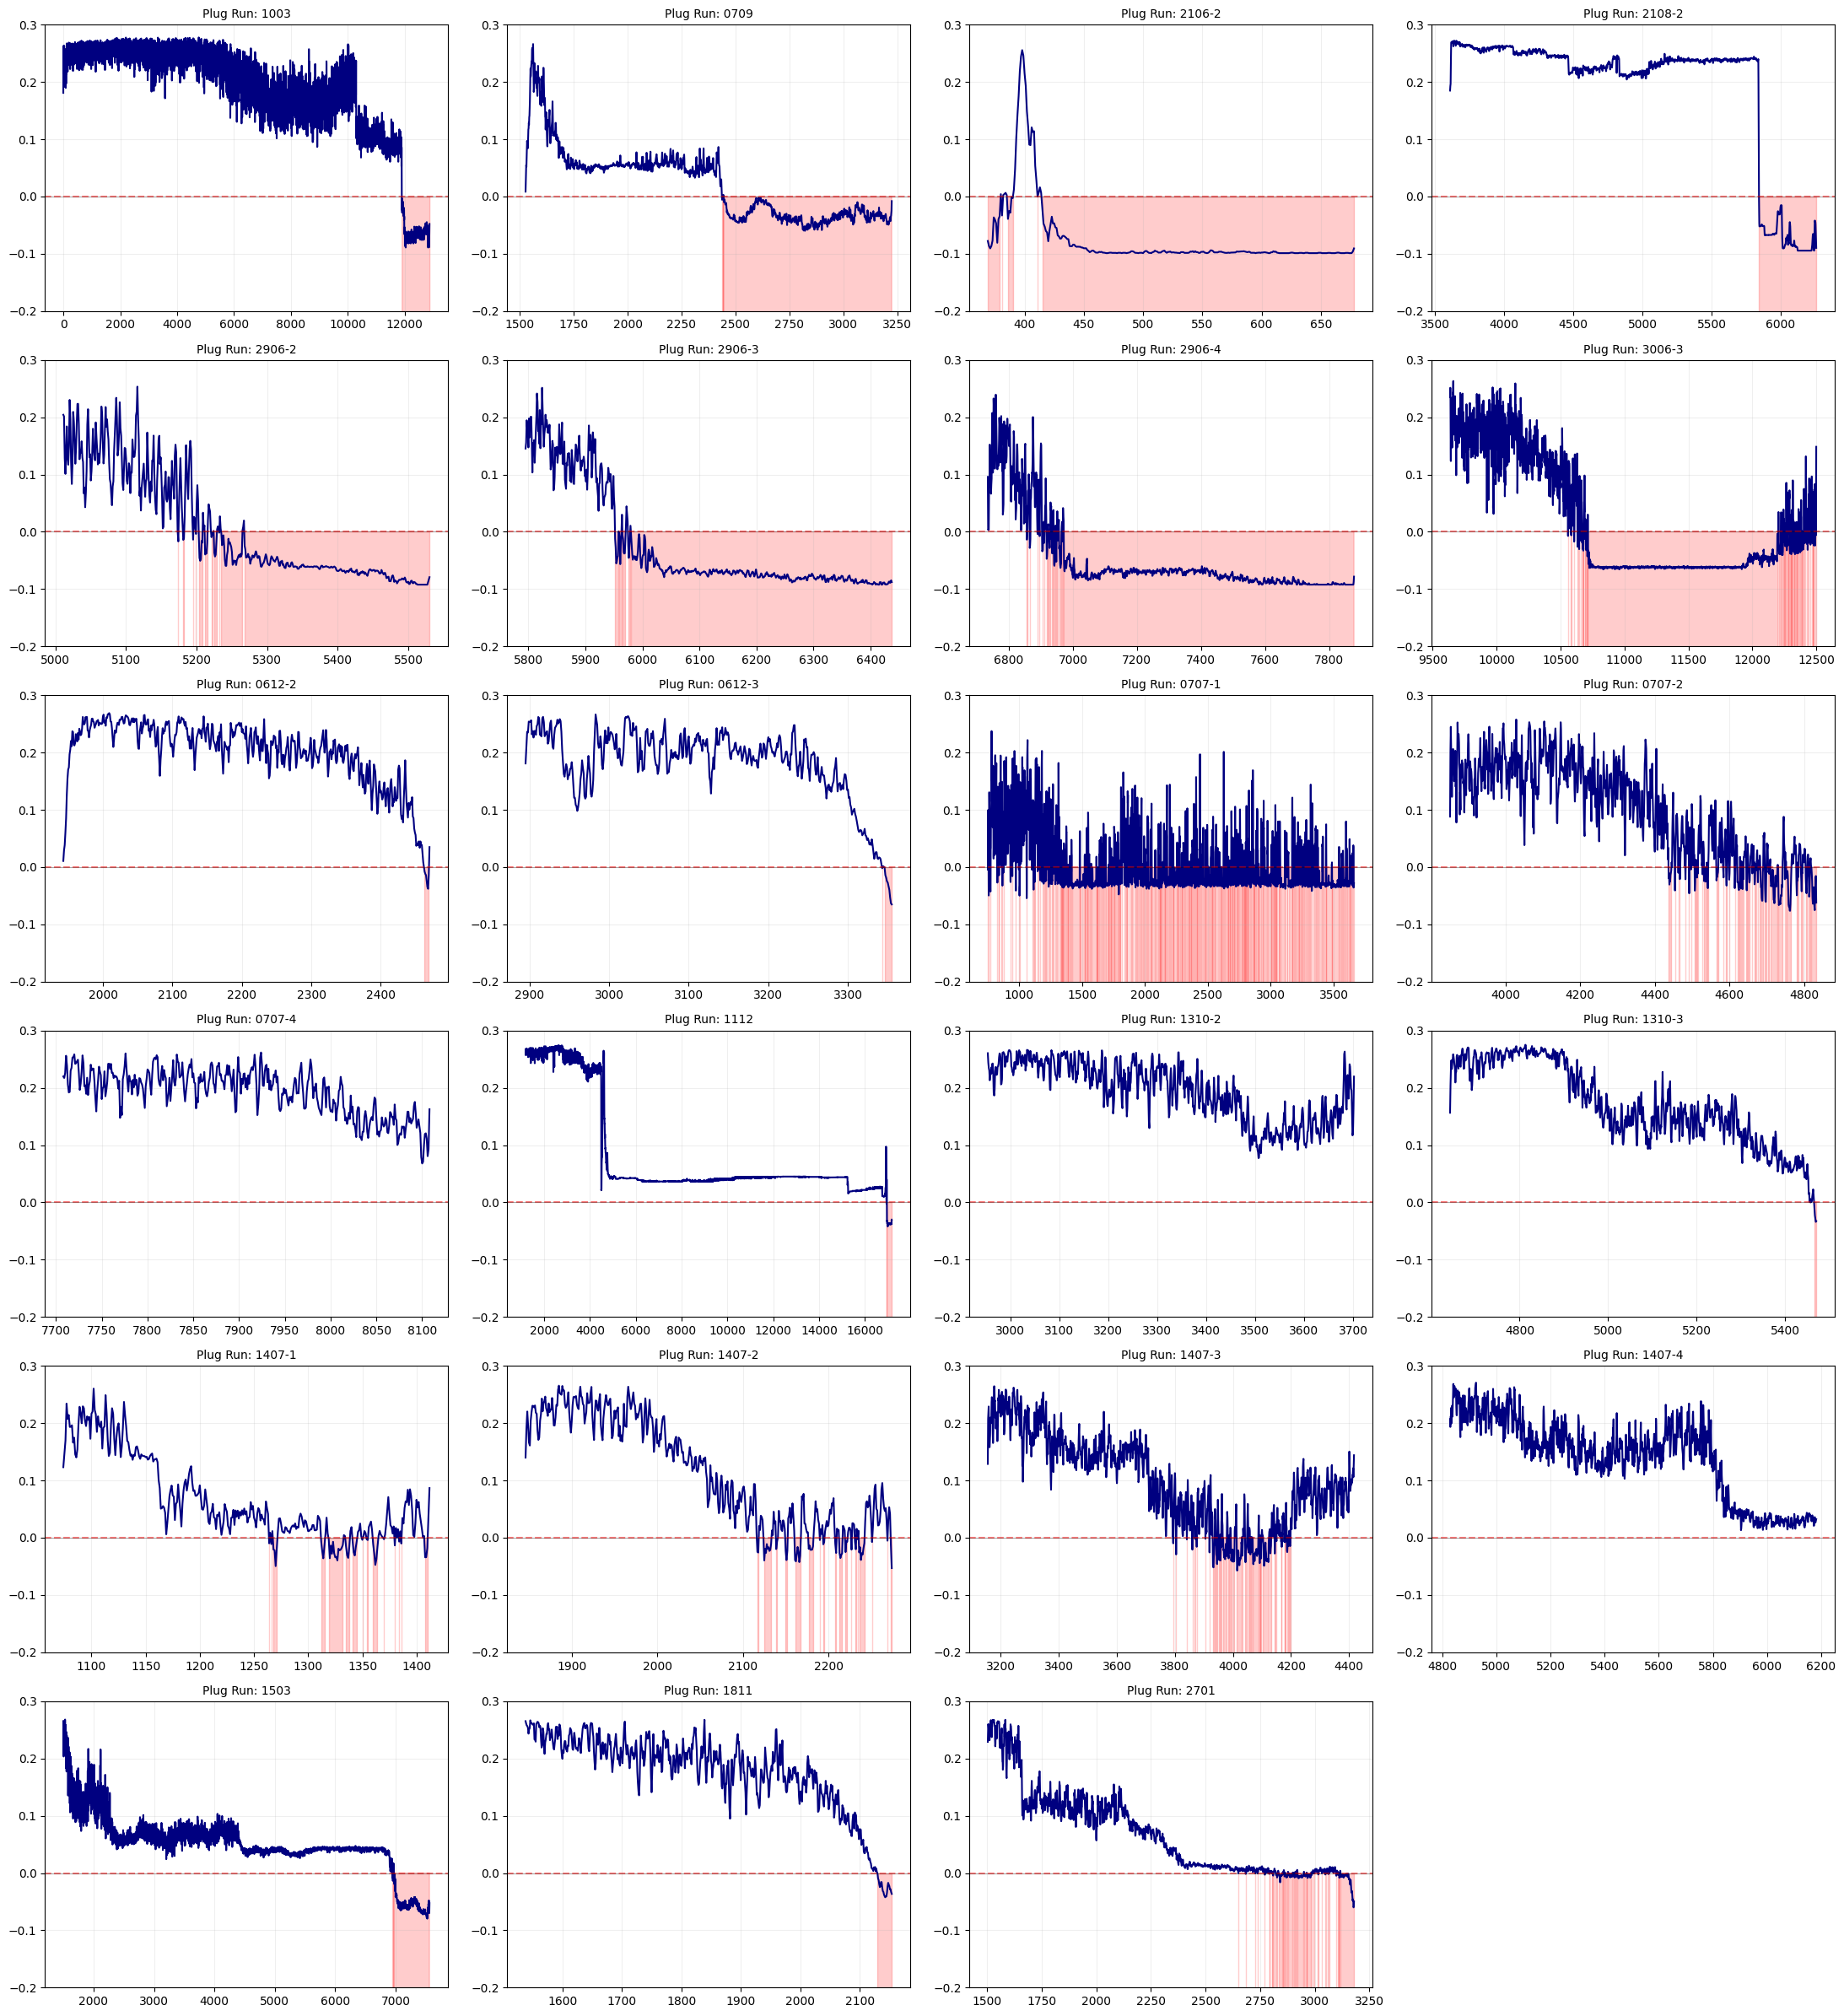

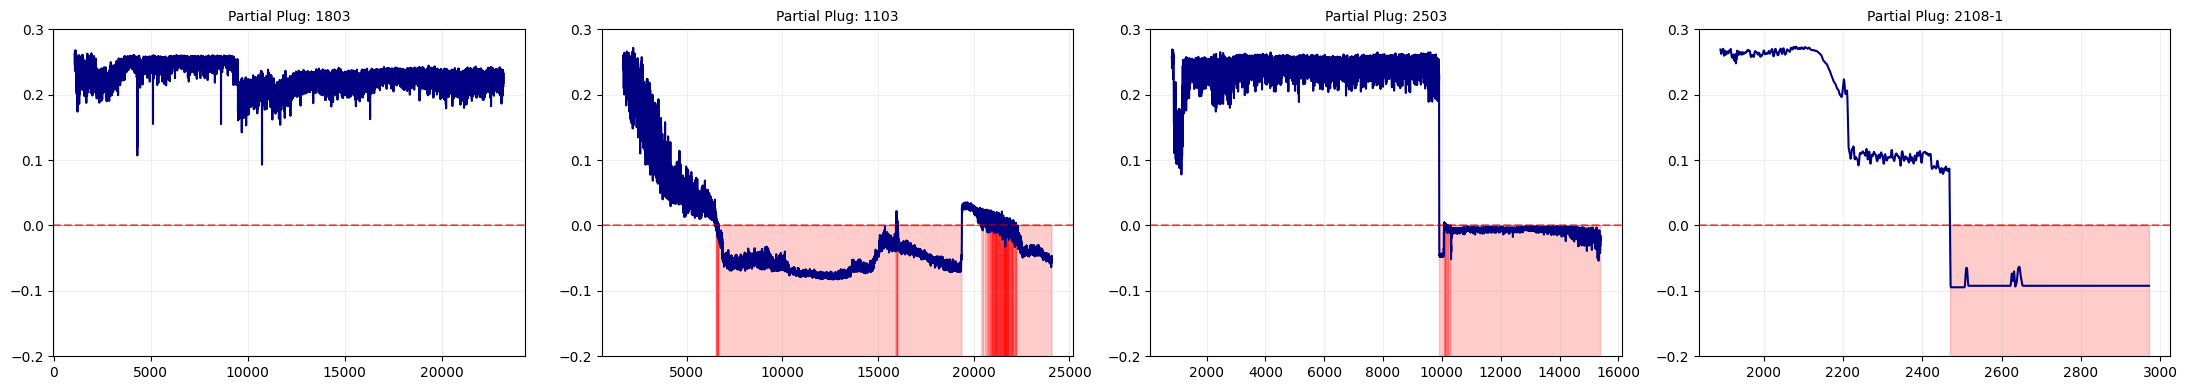

In [66]:
def plot_anomaly_results(df_list, names, title_prefix, threshold=-0.0):
    cols = 4
    rows = math.ceil(len(df_list) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(22, 4 * rows))
    axes = axes.flatten()

    for i, df in enumerate(df_list):
        ax = axes[i]
        
        ax.plot(df['elapsed_runtime_s'], df['smooth_score'], color='navy', label='Anomaly Score')
        
        ax.fill_between(df['elapsed_runtime_s'], -0.5, threshold, 
                        where=(df['smooth_score'] < threshold), color='red', alpha=0.2)
        
        ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.5)
        ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.3) 
        
        ax.set_title(f"{title_prefix}: {names[i]}", fontsize=10)
        ax.set_ylim([-0.2, 0.3]) 
        ax.grid(True, alpha=0.2)


    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# Plot the Plug Runs
plot_anomaly_results(scored_plug, plug_names, "Plug Run")

# Plot the Partial Plug Runs
plot_anomaly_results(scored_partial, partial_plug_names, "Partial Plug")

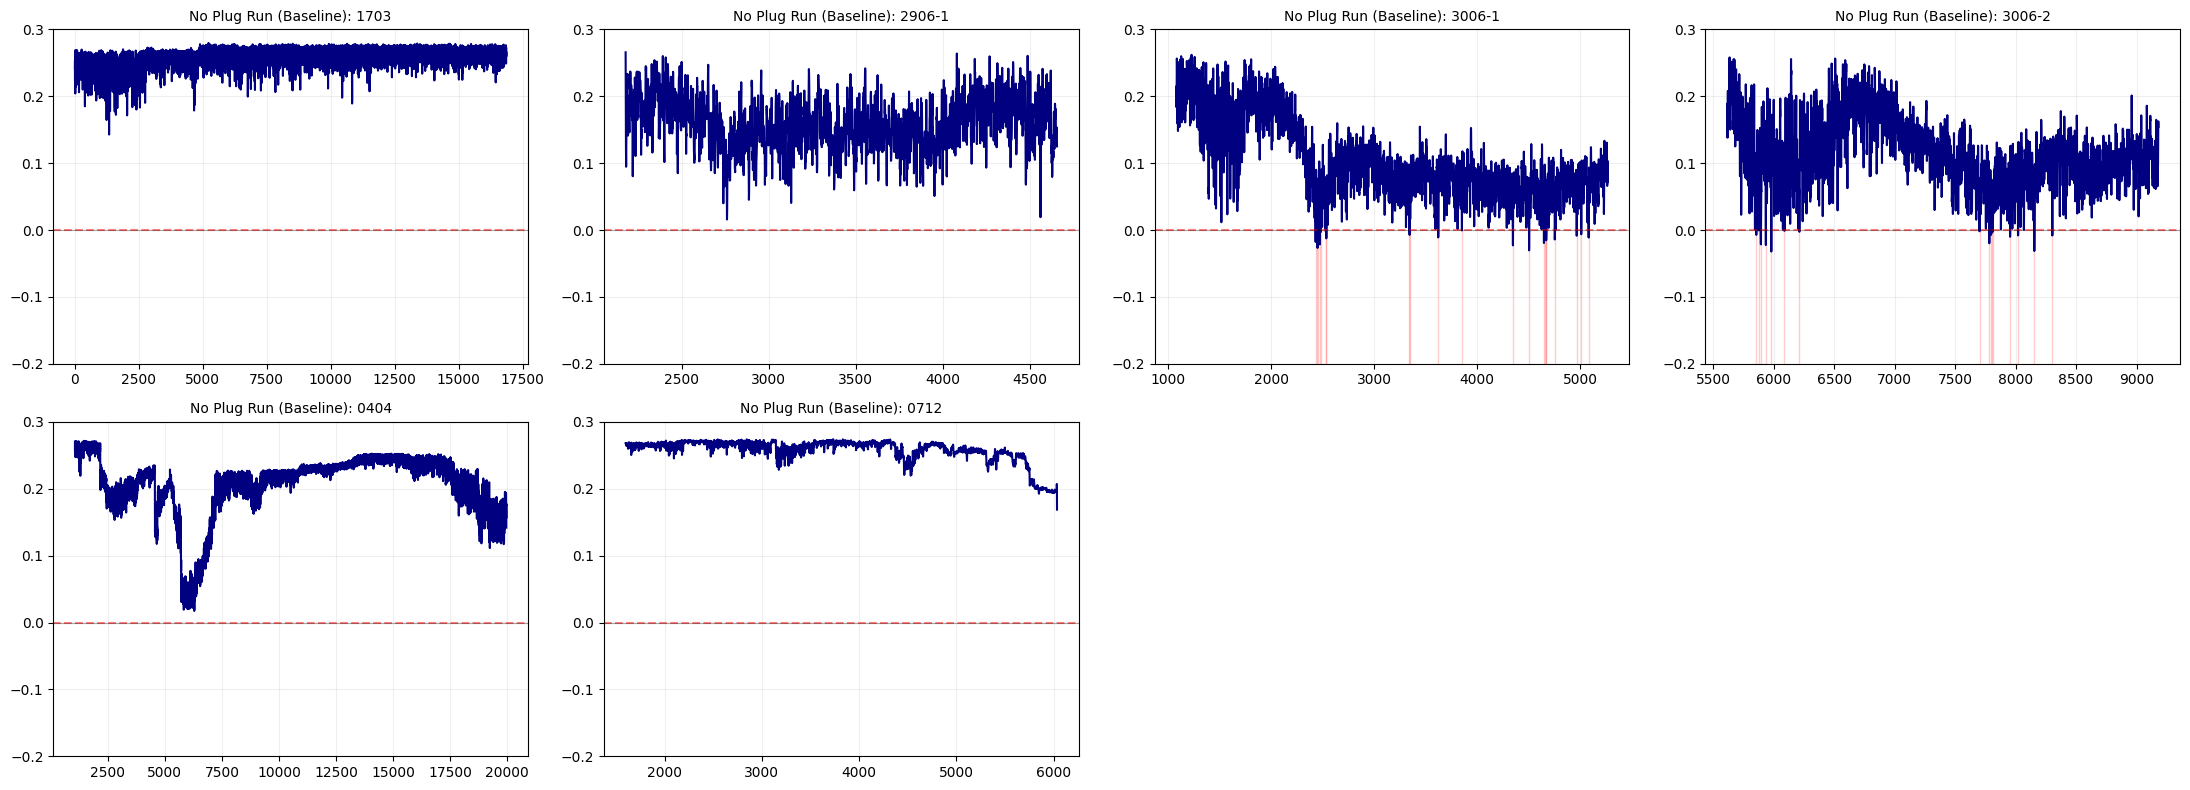

In [ ]:
plot_anomaly_results(scored_no_plug, no_plug_names, "No Plug Run (Baseline)")